# Vectorless RAG: Multi-Hop Claims Adjudication & Benefit Tables

This notebook demonstrates two advanced use cases where Vectorless RAG outperforms standard chunking-based RAG:

1. **Multi-Hop Claims Adjudication** — fetching discrete variables (dates, deductibles, limits) from different parts of a policy without introducing noise.
2. **Benefit Tables & Rate Charts** — retrieving whole logical nodes that preserve table structure, headers, and footnotes.

Standard Vector RAG often fails here because:
- Chunking shatters tables and cross-references.
- Embedding similarity retrieves irrelevant nearby text.
- Multi-hop reasoning requires fetching multiple distant nodes, which chunking mixes together.

## 1. Prerequisites

This notebook assumes you have:

- A complex insurance policy PDF in a local `data/` folder.
- A PageIndex API key for tree generation.
- A Groq API key for the free LLM endpoint.

The LLM layer uses [Groq](https://groq.com/) via its OpenAI-compatible endpoint. You can choose between `llama-3.3-70b-versatile` (larger) and `llama-3.1-8b-instant` (faster) at runtime.

### API Key Setup

You will need two API keys:

| Key | Where to get it |
|-----|------------------|
| `GROQ_API_KEY` | [https://console.groq.com/keys](https://console.groq.com/keys) |
| `PAGEINDEX_API_KEY` | [https://www.pageindex.ai](https://www.pageindex.ai) |

Set them as environment variables or in a `.env` file in the same directory as this notebook:

```
GROQ_API_KEY=gsk_...
PAGEINDEX_API_KEY=...
```

In [1]:
%pip install -q --upgrade pageindex openai python-dotenv pymupdf networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

The notebook reads API keys from a `.env` file or environment variables. If neither is set, you'll be prompted to paste them interactively.

- `GROQ_API_KEY`: Groq API key (from [console.groq.com/keys](https://console.groq.com/keys)).
- `PAGEINDEX_API_KEY`: PageIndex API key.
- `PDF_NAME`: Optional filename in `data/` if you want to pin a specific PDF.

You will be prompted to choose between two Groq models at runtime:
- `llama-3.3-70b-versatile` — larger, more capable.
- `llama-3.1-8b-instant` — faster, lighter.

Groq provides a free OpenAI-compatible endpoint, so no `LLM_BASE_URL` is needed.

In [3]:
from pathlib import Path
import json
import os
import re
import time
from typing import Any

from dotenv import load_dotenv
from openai import AsyncOpenAI
from pageindex import PageIndexClient
import pageindex.utils as pi_utils

load_dotenv()

DATA_DIR = Path("data")
CACHE_DIR = DATA_DIR / "cache"
LLM_BASE_URL = "https://api.groq.com/openai/v1"
PDF_NAME = os.getenv("PDF_NAME")

# Load keys from .env, or prompt user to enter them
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY", "").strip()
LLM_API_KEY = os.getenv("GROQ_API_KEY", "").strip()

if not PAGEINDEX_API_KEY:
    PAGEINDEX_API_KEY = input("Paste your PAGEINDEX_API_KEY (from pageindex.ai): ").strip()
if not LLM_API_KEY:
    LLM_API_KEY = input("Paste your GROQ_API_KEY (from console.groq.com/keys): ").strip()

print(f"PAGEINDEX_API_KEY: {'set' if PAGEINDEX_API_KEY else 'NOT SET'}")
print(f"GROQ_API_KEY: {'set' if LLM_API_KEY else 'NOT SET'}")

MODELS = {
    "1": ("llama-3.3-70b-versatile", "Llama 3.3 70B — larger, more capable"),
    "2": ("llama-3.1-8b-instant", "Llama 3.1 8B — faster, lighter"),
}

print("Choose an LLM model:")
for key, (name, desc) in MODELS.items():
    print(f"  {key}. {name} — {desc}")

choice = input("Enter 1 or 2: ").strip()
LLM_MODEL = MODELS.get(choice, MODELS["1"])[0]
print(f"Using model: {LLM_MODEL}")

pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY) if PAGEINDEX_API_KEY else None
llm_client = AsyncOpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL) if LLM_API_KEY else None


def extract_json(text: str) -> dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
        raise ValueError(f"Expected JSON output, got: {text[:500]}")
    return json.loads(match.group(0))


async def call_llm(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> str:
    if llm_client is None:
        raise RuntimeError("GROQ_API_KEY is not configured.")
    response = await llm_client.chat.completions.create(
        model=model,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    return response.choices[0].message.content.strip()


def preview_text(text: str, limit: int = 1200) -> str:
    text = text.strip()
    return text if len(text) <= limit else text[:limit].rstrip() + "..."

PAGEINDEX_API_KEY: set
GROQ_API_KEY: set
Choose an LLM model:
  1. llama-3.3-70b-versatile — Llama 3.3 70B — larger, more capable
  2. llama-3.1-8b-instant — Llama 3.1 8B — faster, lighter


Enter 1 or 2:  1


Using model: llama-3.3-70b-versatile


## 3. Load a PDF from `data/`

This notebook works with one user-provided PDF at a time. If `PDF_NAME` is set, the notebook uses that file from `data/`; otherwise it uses the first PDF it finds.

For this lab, use a complex insurance policy PDF that contains multi-section clauses, effective dates, deductibles, and rate tables.

In [4]:
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Missing data folder: {DATA_DIR.resolve()}")

pdf_candidates = sorted(DATA_DIR.glob("*.pdf"))
if not pdf_candidates:
    raise FileNotFoundError(f"No PDF files found in {DATA_DIR.resolve()}")

if PDF_NAME:
    matching = [path for path in pdf_candidates if path.name == PDF_NAME]
    if not matching:
        available = ", ".join(path.name for path in pdf_candidates)
        raise FileNotFoundError(f"PDF_NAME={PDF_NAME!r} was not found in data/. Available files: {available}")
    pdf_path = matching[0]
else:
    pdf_path = pdf_candidates[0]

print(f"Using PDF: {pdf_path}")

Using PDF: data/synthetic_insurance_policy_CMP-2026-0417-IN.pdf


## 4. Build the PageIndex tree

This cell submits the selected PDF to PageIndex and retrieves the generated tree.

The tree is cached locally in `data/cache/` so subsequent runs skip the PageIndex API call for the same document.

If the document is still processing, the notebook polls with a progress bar until the tree is ready.

In [5]:
CACHE_DIR.mkdir(exist_ok=True)
cache_path = CACHE_DIR / f"{pdf_path.stem}_tree.json"

if cache_path.exists():
    print(f"Loading cached tree from {cache_path}")
    tree = json.loads(cache_path.read_text())
else:
    if pi_client is None:
        raise RuntimeError("PAGEINDEX_API_KEY is not configured.")

    submitted = pi_client.submit_document(str(pdf_path))
    doc_id = submitted.get("doc_id") or submitted.get("result", {}).get("doc_id")
    if not doc_id:
        raise RuntimeError(f"Could not read doc_id from PageIndex response: {submitted}")

    print(f"Submitted document id: {doc_id}")
    print("Waiting for PageIndex to process the document...")

    poll_interval = 5
    max_wait = 300
    elapsed = 0
    spinner = ["|", "/", "-", "\\"]
    while elapsed < max_wait:
        if pi_client.is_retrieval_ready(doc_id):
            break
        idx = (elapsed // poll_interval) % len(spinner)
        print(f"\r  {spinner[idx]}  Waiting... {elapsed}s / {max_wait}s", end="", flush=True)
        time.sleep(poll_interval)
        elapsed += poll_interval
    else:
        raise RuntimeError(
            f"PageIndex did not finish within {max_wait}s. Rerun this cell later."
        )
    print(f"\r  Done! Processed in {elapsed}s.{' ' * 20}")

    tree_response = pi_client.get_tree(doc_id, node_summary=True)
    tree = tree_response.get("result", tree_response)

    cache_path.write_text(json.dumps(tree))
    print(f"Tree cached to {cache_path}")

print("Tree ready. Top-level preview:")
pi_utils.print_tree(tree[:2] if isinstance(tree, list) else tree)

Loading cached tree from data/cache/synthetic_insurance_policy_CMP-2026-0417-IN_tree.json
Tree ready. Top-level preview:
[{'title': 'Commercial Multi-Peril Insurance Policy',
  'node_id': '0000',
  'prefix_summary': '# Commercial Multi-Peril Insurance Polic...',
  'nodes': [{'title': 'Contents',
             'node_id': '0001',
             'summary': 'This document outlines a Commercial Mult...'},
            {'title': '1 DECLARATIONS',
             'node_id': '0002',
             'summary': 'This document outlines the insurance dec...'},
            {'title': '2 DEFINITIONS',
             'node_id': '0003',
             'prefix_summary': '## 2 DEFINITIONS\n',
             'nodes': [{'title': '2.1 Aggregate Limit',
                        'node_id': '0004',
                        'summary': "### 2.1 Aggregate Limit\n\n'Aggregate Limi..."},
                       {'title': '2.2 Bodily Injury',
                        'node_id': '0005',
                        'summary': "### 2.2 Bodily

## 5. Prepare retrieval helpers

The next cells use the tree structure for two passes:

1. Tree search: the LLM selects the node IDs most likely to contain the answer.
2. Evidence extraction: the notebook pulls the full text for those nodes and passes it into the final answer prompt.

This keeps the workflow vectorless while still giving you transparent, inspectable retrieval decisions.

In [6]:
node_map = pi_utils.create_node_mapping(tree)

def tree_as_prompt_text(document_tree: object) -> str:
    tree_copy = document_tree.copy() if isinstance(document_tree, dict) else document_tree
    tree_without_text = pi_utils.remove_fields(tree_copy, fields=["text"])
    return json.dumps(tree_without_text, indent=2)


def collect_node_text(node_ids: list[str]) -> str:
    parts: list[str] = []
    for node_id in node_ids:
        node = node_map.get(node_id)
        if not node:
            continue
        text = node.get("text", "")
        title = node.get("title", node_id)
        page_index = node.get("page_index", "?")
        parts.append(f"[node={node_id} page={page_index} title={title}]\n{text}")
    return "\n\n".join(parts)


print(f"Indexed nodes: {len(node_map)}")

Indexed nodes: 34


---

## Scenario A: Multi-Hop Claims Adjudication

### The Problem

When adjudicating an insurance claim, you often need to cross-reference **multiple distant sections** of a policy:

- **Effective Dates** (when does coverage apply?)
- **Deductible Limits** (what does the insured pay first?)
- **Coverage Caps** (what is the maximum payout?)

Standard chunking-based RAG retrieves a single chunk. If the effective dates and deductible limits are in different sections (pages 2 and 15), chunking either misses one or mixes in irrelevant surrounding text.

Vectorless RAG solves this by letting the LLM reason over the **entire tree** and explicitly select multiple node IDs — even if they are far apart in the document.

### Step A1: Define the adjudication question

Ask a question that requires fetching facts from multiple sections of the policy.

In [8]:
ADJUDICATION_QUESTION = input(
    "Enter a multi-hop claims question (e.g., 'Is this claim within the effective dates and below the deductible limit?'): "
).strip()
if not ADJUDICATION_QUESTION:
    raise ValueError("A question is required to continue.")

Enter a multi-hop claims question (e.g., 'Is this claim within the effective dates and below the deductible limit?'):  What's the final annual premium for an Individual, Band C, Zone A, Age Band AG4, with the Critical Illness Rider attached, on a 2-year policy term?


### Step A2: Multi-hop tree search

The LLM receives the full document tree and explicitly identifies **which sections** to fetch. It returns a structured response with:
- `thinking`: why each node was selected.
- `node_list`: the node IDs to retrieve.
- `cross_references`: directed links between nodes where one section references or relies on another (e.g., Declarations citing a Deductible definition).

This is the key advantage over chunking: the LLM can select **any combination of nodes** across the entire document and explain how they connect.

In [9]:
retrieval_system_prompt = """
You are a document retrieval assistant for a multi-hop insurance claims adjudication system.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question may require information from MULTIPLE distant sections of the policy.

Identify ALL node IDs that contain relevant evidence. Common patterns:
- Effective Dates / Policy Period
- Deductible Limits / Waiting Periods
- Coverage Caps / Sublimits
- Exclusions / Conditions
- Definition sections that clarify terms used elsewhere

For each pair of nodes where one references or relies on the other (e.g., a Declarations
page citing a Definition, or a Coverage section pointing to a Deductible schedule),
describe that cross-reference in the cross_references array.

Return valid JSON with this shape:
{
  "thinking": "step-by-step reasoning about which sections are needed and why",
  "node_list": ["node_id_1", "node_id_2", ...],
  "cross_references": [
    {
      "source": "node_id_1",
      "target": "node_id_2",
      "reason": "short explanation of why node_id_1 redirects to node_id_2"
    }
  ]
}

If no cross-references exist between the selected nodes, return an empty array for cross_references.
Do not output markdown, prose, or extra keys.
Be thorough — missing a required node means an incomplete adjudication.
""".strip()

retrieval_user_prompt = f"""
Question:
{ADJUDICATION_QUESTION}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()

retrieval_response = await call_llm(retrieval_system_prompt, retrieval_user_prompt)
retrieval_json = extract_json(retrieval_response)
selected_node_ids = retrieval_json.get("node_list", [])
cross_references = retrieval_json.get("cross_references", [])

print(f"Selected {len(selected_node_ids)} node(s):", selected_node_ids)
print(f"Cross-references: {len(cross_references)}")
for ref in cross_references:
    print(f"  {ref.get('source')} -> {ref.get('target')}: {ref.get('reason', '')}")
print("\nRetrieval reasoning:")
print(retrieval_json.get("thinking", ""))

Selected 4 node(s): ['0002', '0003', '0031', '0032']
Cross-references: 3
  0002 -> 0031: The Declarations section may reference the Schedule of Limits and Deductibles for specific policy details.
  0003 -> 0032: Definitions may be referenced or expanded upon in the Endorsements section, especially for terms related to specific riders or coverage extensions.
  0031 -> 0032: The Schedule of Limits and Deductibles may reference specific endorsements that apply to the policy, including those related to riders like Critical Illness.

Retrieval reasoning:
To determine the final annual premium for an Individual, Band C, Zone A, Age Band AG4, with the Critical Illness Rider attached, on a 2-year policy term, we need to identify relevant sections in the policy document. The policy document provided does not directly mention 'Individual' or 'Band C, Zone A, Age Band AG4' in the given sections, which suggests that the specific premium details for such a profile might not be directly available in 

### Visualizing the Multi-Hop Retrieval

The diagram below shows the LLM's logical navigation path through the policy tree.
Directed arrows indicate cross-references — where one section redirects to another
(e.g., Declarations referencing a Deductible defined elsewhere). Dashed lines show
the underlying document tree hierarchy for context.

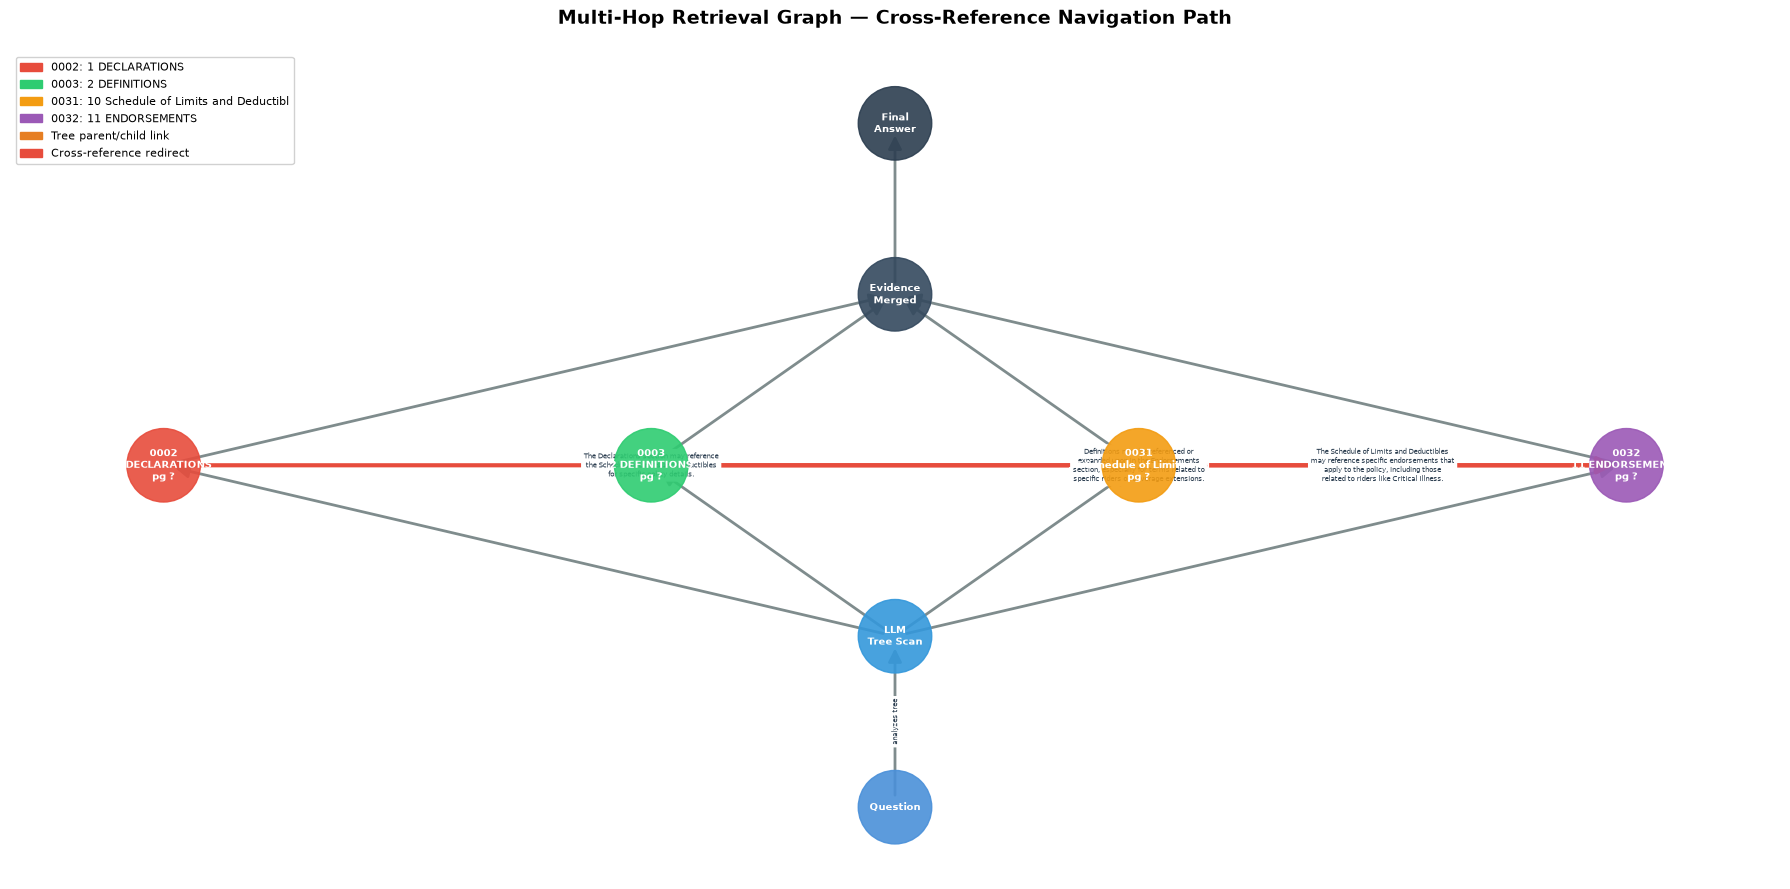

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

G = nx.DiGraph()

node_info = []
for nid in selected_node_ids:
    node = node_map.get(nid, {})
    title = node.get('title', nid)
    page = node.get('page', '?')
    parent = node.get('parent_id', None)
    node_info.append({'id': nid, 'title': title, 'page': page, 'parent': parent})

G.add_node("Question", layer=0)
G.add_node("LLM\nTree Scan", layer=1)
G.add_edge("Question", "LLM\nTree Scan", label="analyzes tree")

colors = ["#E74C3C", "#2ECC71", "#F39C12", "#9B59B6", "#1ABC9C"]
node_colors = ["#4A90D9", "#3498DB"]

hop_labels = []
for idx, info in enumerate(node_info):
    hop_label = f"{info['id']}\n{info['title'][:25]}\npg {info['page']}"
    hop_labels.append(hop_label)
    G.add_node(hop_label, layer=2)
    G.add_edge("LLM\nTree Scan", hop_label)
    node_colors.append(colors[idx % len(colors)])

for idx in range(len(node_info)):
    for jdx in range(idx + 1, len(node_info)):
        child = node_info[idx]
        candidate = node_info[jdx]
        if candidate['id'] == child.get('parent'):
            G.add_edge(hop_labels[jdx], hop_labels[idx], style="dashed")
        elif child['id'] == candidate.get('parent'):
            G.add_edge(hop_labels[idx], hop_labels[jdx], style="dashed")

id_to_label = {node_info[i]['id']: hop_labels[i] for i in range(len(node_info))}
cross_ref_edges = []
cross_ref_labels = {}
for ref in cross_references:
    src = ref.get('source', '')
    tgt = ref.get('target', '')
    reason = ref.get('reason', '')
    if src in id_to_label and tgt in id_to_label and src != tgt:
        u, v = id_to_label[src], id_to_label[tgt]
        cross_ref_edges.append((u, v))
        cross_ref_labels[(u, v)] = textwrap.fill(reason, width=40)

G.add_node("Evidence\nMerged", layer=3)
G.add_node("Final\nAnswer", layer=4)
node_colors.append("#34495E")
node_colors.append("#2C3E50")

for hl in hop_labels:
    G.add_edge(hl, "Evidence\nMerged")

G.add_edge("Evidence\nMerged", "Final\nAnswer")

fig, ax = plt.subplots(1, 1, figsize=(20, 12), dpi=150)
pos = nx.multipartite_layout(G, subset_key="layer", align="horizontal")

assert len(node_colors) == len(G.nodes()), f"Color mismatch: {len(node_colors)} colors vs {len(G.nodes())} nodes"

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=4500, alpha=0.9, ax=ax)

solid_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') != 'dashed']
dashed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') == 'dashed']
plain_solid = [(u, v) for u, v in solid_edges if (u, v) not in cross_ref_edges]

nx.draw_networkx_edges(G, pos, edgelist=plain_solid, edge_color="#7F8C8D", arrows=True, arrowsize=20, width=2, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=dashed_edges, edge_color="#E67E22", arrows=True, arrowsize=18, width=2, style="dashed", ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=cross_ref_edges, edge_color="#E74C3C", arrows=True, arrowsize=25, width=4, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=10, font_color="white", font_weight="bold", ax=ax)

edge_labels = {(u, v): d.get('label', '') for u, v, d in G.edges(data=True) if d.get('label')}
edge_labels.update(cross_ref_labels)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color="#2C3E50",
                             bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2), ax=ax)

legend_items = [mpatches.Patch(color=colors[i % len(colors)], label=f"{node_info[i]['id']}: {node_info[i]['title'][:35]}") for i in range(len(node_info))]
legend_items.append(mpatches.Patch(color="#E67E22", label="Tree parent/child link"))
legend_items.append(mpatches.Patch(color="#E74C3C", label="Cross-reference redirect"))
ax.legend(handles=legend_items, loc="upper left", fontsize=9, framealpha=0.9)

ax.set_title("Multi-Hop Retrieval Graph — Cross-Reference Navigation Path", fontsize=16, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

### Step A3: Extract multi-hop evidence

Each selected node is retrieved in full. Because Vectorless RAG fetches **whole logical nodes**, there is no chunking noise — just clean, relevant passages from different parts of the policy.

In [ ]:
evidence_text = collect_node_text(selected_node_ids)
if not evidence_text.strip():
    raise RuntimeError("No evidence text was collected. Check the selected node IDs and tree mapping.")

print("Evidence preview (multi-hop):\n")
print(preview_text(evidence_text, limit=4000))

### Step A4: Generate adjudication answer

The final LLM call receives all the multi-hop evidence and produces a structured adjudication response.

In [ ]:
adjudication_system_prompt = """
You are an insurance claims adjudication assistant.

You have been given evidence from multiple sections of an insurance policy.
Analyze the evidence to answer the adjudication question.

Return valid JSON with this shape:
{
  "decision": "approve" or "deny" or "needs_review",
  "final_answer": "clear, concise answer for the claims adjuster",
  "explainability": {
    "effective_dates": "policy period information found",
    "deductible": "deductible information found",
    "coverage_limits": "coverage cap information found",
    "evidence_used": ["short evidence note 1", "short evidence note 2"]
  }
}

Ground every statement in the provided evidence. Do not invent facts.
""".strip()

adjudication_user_prompt = f"""
Adjudication question:
{ADJUDICATION_QUESTION}

Evidence from policy:
{evidence_text}
""".strip()

adjudication_response = await call_llm(adjudication_system_prompt, adjudication_user_prompt)
adjudication_json = extract_json(adjudication_response)

print("Decision:", adjudication_json.get("decision", ""))
print("\nFinal answer:")
print(adjudication_json.get("final_answer", ""))
print("\nExplainability:")
print(json.dumps(adjudication_json.get("explainability", {}), indent=2))

---

## Scenario B: Benefit Tables & Rate Charts

### The Problem

Insurance policies contain structured tables — rate charts, benefit schedules, co-pay matrices — that are critical for accurate answers.

Standard chunking **shatters** tables:
- A table spanning one page might be split into 3-4 chunks.
- Headers get separated from their rows.
- Footnotes referencing table cells get lost.
- The LLM receives disconnected table fragments with no structural context.

Vectorless RAG retrieves **whole logical nodes**. PageIndex preserves table structure as a single node, so the LLM receives the complete table with headers, data, and footnotes intact.

### Step B1: Define the table query

Ask a question that requires reading a specific rate chart or benefit table.

In [ ]:
TABLE_QUESTION = input(
    "Enter a table-related question (e.g., 'What is the coinsurance rate for out-of-network providers?'): "
).strip()
if not TABLE_QUESTION:
    raise ValueError("A question is required to continue.")

### Step B2: Targeted tree search for tables

The LLM identifies which node(s) contain the relevant table. It also traces its navigation path — how it narrowed down from a parent section or cross-reference index to the specific table node. Because PageIndex preserves table structure, the LLM can reason about table headers and row labels in the tree.

In [ ]:
table_retrieval_prompt = """
You are a document retrieval assistant specializing in structured data.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question likely requires information from a TABLE, CHART, or SCHEDULE in the document.

Look for nodes that contain:
- Rate charts / premium tables
- Benefit schedules / co-pay matrices
- Coverage limit tables
- Any node whose title or summary suggests tabular data

Trace how you narrowed down to the target table. For example, if you started at a
Table of Contents or parent section and then navigated to a specific table node,
describe that search path in cross_references.

Return valid JSON with this shape:
{
  "thinking": "which table or schedule was identified and why it matches the question",
  "node_list": ["node_id_1", "node_id_2"],
  "cross_references": [
    {
      "source": "node_id_of_parent_or_index",
      "target": "node_id_of_table",
      "reason": "navigated from index/section to the specific table"
    }
  ]
}

If no cross-references exist, return an empty array for cross_references.
Do not output markdown, prose, or extra keys.
Prefer retrieving the ENTIRE table node over partial fragments.
""".strip()

table_user_prompt = f"""
Question:
{TABLE_QUESTION}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()

table_response = await call_llm(table_retrieval_prompt, table_user_prompt)
table_json = extract_json(table_response)
table_node_ids = table_json.get("node_list", [])
table_cross_refs = table_json.get("cross_references", [])

print(f"Selected {len(table_node_ids)} node(s):", table_node_ids)
print(f"Cross-references: {len(table_cross_refs)}")
for ref in table_cross_refs:
    print(f"  {ref.get('source')} -> {ref.get('target')}: {ref.get('reason', '')}")
print("\nRetrieval reasoning:")
print(table_json.get("thinking", ""))

### Visualizing the Table Retrieval

The diagram below shows the LLM's sequential search path to locate the table.
Directed red arrows indicate how the LLM narrowed down from a parent section or
cross-reference index to the specific table node. Greyed-out sections were scanned
but not selected.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

table_titles = []
for nid in table_node_ids:
    node = node_map.get(nid, {})
    title = node.get('title', nid)
    page = node.get('page', '?')
    table_titles.append((nid, title, page))

T = nx.DiGraph()

tree_sections = [
    "1 DECLARATIONS",
    "2 DEFINITIONS",
    "3 INSURING AGREEMENTS",
    "4 PROPERTY DAMAGE",
    "5 GENERAL LIABILITY",
    "6 CYBER & DATA BREACH",
    "7 GENERAL EXCLUSIONS",
    "8 CONDITIONS",
    "9 CLAIMS PROCEDURE",
    "10 Schedule of Limits",
    "11 ENDORSEMENTS",
    "12 Cross-Reference Index",
]

T.add_node("Document\nTree", layer=0)

for section in tree_sections:
    T.add_node(section, layer=1)
    T.add_edge("Document\nTree", section)

T.add_node("LLM\nIdentifies\nTable", layer=2)
T.add_node("Retrieve\nFull Table", layer=3)
T.add_node("Answer", layer=4)

for section in tree_sections:
    T.add_edge(section, "LLM\nIdentifies\nTable")

T.add_edge("LLM\nIdentifies\nTable", "Retrieve\nFull Table")
T.add_edge("Retrieve\nFull Table", "Answer")

node_colors = []
node_sizes = []
selected_names = [x[1] for x in table_titles]
for node in T.nodes():
    if node in selected_names:
        node_colors.append("#E74C3C")
        node_sizes.append(4500)
    elif node == "Document\nTree":
        node_colors.append("#4A90D9")
        node_sizes.append(3500)
    elif node in ["LLM\nIdentifies\nTable", "Retrieve\nFull Table", "Answer"]:
        node_colors.append("#2ECC71")
        node_sizes.append(3500)
    else:
        node_colors.append("#BDC3C7")
        node_sizes.append(3000)

cross_ref_edges = []
cross_ref_labels = {}
for ref in table_cross_refs:
    src_id = ref.get('source', '')
    tgt_id = ref.get('target', '')
    reason = ref.get('reason', '')
    src_node = node_map.get(src_id, {})
    tgt_node = node_map.get(tgt_id, {})
    src_name = src_node.get('title', src_id)
    tgt_name = tgt_node.get('title', tgt_id)
    if src_name in [s for s in tree_sections] or src_name in selected_names:
        if tgt_name in selected_names:
            cross_ref_edges.append((src_name, tgt_name))
            cross_ref_labels[(src_name, tgt_name)] = textwrap.fill(reason, width=35)

fig, ax = plt.subplots(1, 1, figsize=(20, 12), dpi=150)
pos = nx.multipartite_layout(T, subset_key="layer", align="horizontal")

nx.draw_networkx_nodes(T, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)

plain_edges = [(u, v) for u, v in T.edges() if (u, v) not in cross_ref_edges]
nx.draw_networkx_edges(T, pos, edgelist=plain_edges, edge_color="#7F8C8D", arrows=True, arrowsize=15, width=1.5, alpha=0.6, ax=ax)
nx.draw_networkx_edges(T, pos, edgelist=cross_ref_edges, edge_color="#E74C3C", arrows=True, arrowsize=25, width=4, ax=ax)

nx.draw_networkx_labels(T, pos, font_size=10, font_color="white", font_weight="bold", ax=ax)

if cross_ref_labels:
    nx.draw_networkx_edge_labels(T, pos, edge_labels=cross_ref_labels, font_size=9, font_color="#2C3E50",
                                 bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2), ax=ax)

legend_items = [
    mpatches.Patch(color="#4A90D9", label="Document Tree"),
    mpatches.Patch(color="#BDC3C7", label="Other Sections (scanned)"),
    mpatches.Patch(color="#E74C3C", label="Selected Table Node"),
    mpatches.Patch(color="#2ECC71", label="Processing Steps"),
    mpatches.Patch(color="#E74C3C", label="Cross-reference navigation"),
]
ax.legend(handles=legend_items, loc="upper left", fontsize=9, framealpha=0.9)

ax.set_title("Table Retrieval Graph — Sequential Search Path", fontsize=16, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

### Step B3: Extract table evidence

The full table node is retrieved. Notice how the complete structure — headers, rows, footnotes — is preserved.

In [ ]:
table_evidence = collect_node_text(table_node_ids)
if not table_evidence.strip():
    raise RuntimeError("No table evidence was collected. Check the selected node IDs.")

print("Table evidence preview:\n")
print(preview_text(table_evidence, limit=4000))

### Step B4: Generate table-based answer

The final LLM call reads the complete table and answers the specific rate/benefit question.

In [ ]:
table_answer_prompt = """
You are an insurance benefits assistant answering questions from rate charts and tables.

You have been given complete table data extracted from a policy document.
Answer the user's question by reading the table carefully.

Return valid JSON with this shape:
{
  "final_answer": "specific answer with exact numbers, rates, or limits from the table",
  "table_structure": {
    "table_title": "name or section of the table",
    "relevant_row": "the specific row or cell that answers the question",
    "relevant_column": "the specific column or category"
  },
  "explainability": {
    "evidence_used": ["specific table excerpt that was used"]
  }
}

Always include exact numbers and rates from the table. Do not approximate.
""".strip()

table_answer_user = f"""
Question:
{TABLE_QUESTION}

Table data:
{table_evidence}
""".strip()

table_final_response = await call_llm(table_answer_prompt, table_answer_user)
table_final_json = extract_json(table_final_response)

print("Final answer:")
print(table_final_json.get("final_answer", ""))
print("\nTable reference:")
print(json.dumps(table_final_json.get("table_structure", {}), indent=2))
print("\nExplainability:")
print(json.dumps(table_final_json.get("explainability", {}), indent=2))